<a href="https://colab.research.google.com/github/muskanmathur2706-cloud/SVM--Supervised-Learning/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('Social_Network_Ads.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
df.head(3)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


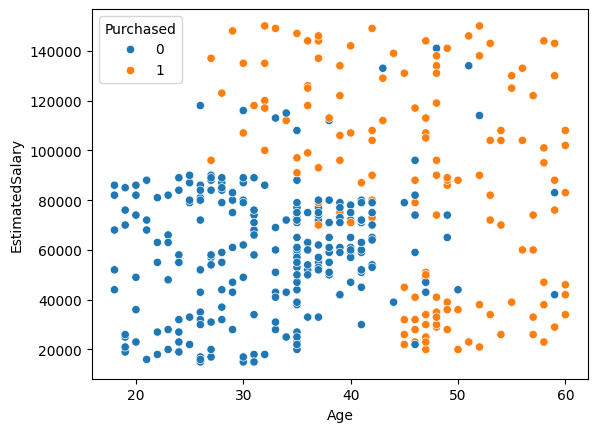

In [ ]:
sns.scatterplot(data=df,x='Age',y='EstimatedSalary',hue='Purchased')
plt.show()

In [ ]:
import pandas as pd
df=pd.read_csv("Social_Network_Ads.csv")
df=pd.get_dummies(df,columns=['Gender'],drop_first=True)
df.head()

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,19,19000,0,True
1,15810944,35,20000,0,True
2,15668575,26,43000,0,False
3,15603246,27,57000,0,False
4,15804002,19,76000,0,True


In [ ]:
import plotly.express as px

In [ ]:
fig=px.scatter_3d(df,x='Age',y='EstimatedSalary',z='Gender_Male',color='Purchased')
fig.show()

In [ ]:
X=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[['Age','EstimatedSalary']]=scaler.fit_transform(X_train[['Age','EstimatedSalary']])
X_test[['Age','EstimatedSalary']]=scaler.transform(X_test[['Age','EstimatedSalary']])

In [ ]:
X_train.head(3)

,Age,EstimatedSalary
3,-1.066752,-0.386344
18,0.797535,-1.229939
202,0.110692,1.853544


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
model=SVC(kernel='linear')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8625

In [ ]:
model=SVC(kernel='linear')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)


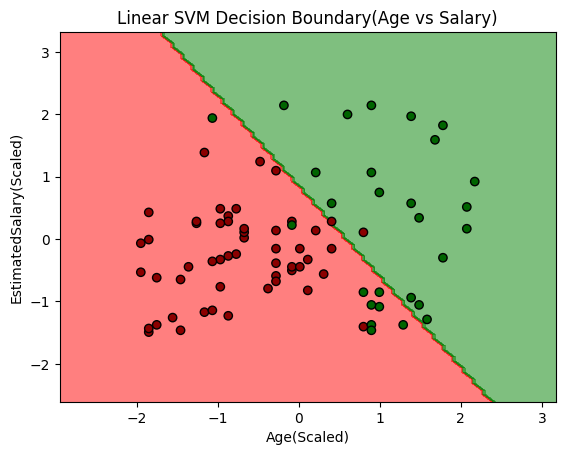

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import ListedColormap
disp = DecisionBoundaryDisplay.from_estimator(
    model,
    X_train[['Age', 'EstimatedSalary']],
    response_method="predict",
    cmap=ListedColormap(["red", "green"]),
    xlabel='Age(Scaled)',
    ylabel='EstimatedSalary(Scaled)',
    alpha=0.5,
)
plt.scatter(X_test['Age'],X_test['EstimatedSalary'],c=y_test,edgecolors='k',cmap=ListedColormap(('darkred','darkgreen')))
plt.title('Linear SVM Decision Boundary(Age vs Salary)')
plt.show()